In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import fsolve

In [2]:
rolling_window = 21

c = 0.99
inverse_cdf = norm.ppf(1-c)
factor = inverse_cdf
print(f'Exact value of Normal ICDF for p = {1-c:.2f} is: \033[1m{inverse_cdf}\033[0m')

Exact value of Normal ICDF for p = 0.01 is: -2.3263478740408408


In [3]:
data = pd.read_excel('Indices_Download_2026.xlsx', index_col='Date')
# 'Date' parsed as datetime, if not automatic
data.index = pd.to_datetime(data.index)
data.head()

,^GSPC,^NDX
Date,,
2015-10-15,2023.859985,4418.220215
2015-10-16,2033.109985,4438.620117
2015-10-19,2033.660034,4462.069824
2015-10-20,2030.770020,4438.180176
2015-10-21,2018.939941,4413.520020


In [5]:
data['LogReturn'] = np.log(data['^GSPC']) - np.log(data['^GSPC'].shift(1))
#xl['Mean'] = xl['LogReturn'].rolling(21, min_periods=21).mean()
# data['SD'] = data['LogReturn'].rolling(rolling_window, min_periods=rolling_window).std()

In [9]:
# data['a'] = data['^GSPC'].shift(-1)
# data['b'] = data['^GSPC'].shift(-11)
# data['c'] = np.log(data['b']) - np.log(data['a'])
data['Forward10dReturn'] = np.log(data['^GSPC'].shift(-11)) - np.log(data['^GSPC'].shift(-1))

In [11]:
data = data.loc['2025-01-01':'2026-01-15']
total_count = data.shape[0]
print(f'Total number of observations: {total_count}')

Total number of observations: 260


In [12]:
# 计算总体方差
overall_variance = data['LogReturn'].var()
print(f'Overall variance of log returns: {overall_variance:.6f}')

Overall variance of log returns: 0.000133


In [14]:
param = 0.72

data.loc[data.index[0], 'variance'] = overall_variance

for i in range(1, len(data)):
    data.loc[data.index[i], 'variance'] = (
        param * data.loc[data.index[i - 1], 'variance']
        + (1 - param) * data.loc[data.index[i], 'LogReturn']**2
    )

data.head(10)

,^GSPC,^NDX,LogReturn,Forward10dReturn,variance
Date,,,,,
2025-01-02,5868.549805,20975.619141,-0.002226,0.017808,0.000133
2025-01-03,5942.470215,21326.160156,0.012517,0.018404,0.000140
2025-01-06,5975.379883,21559.500000,0.005523,0.034870,0.000109
2025-01-07,5909.029785,21173.039062,-0.011166,0.030451,0.000114
2025-01-08,5918.250000,21180.970703,0.001559,0.031295,0.000082
2025-01-10,5827.040039,20847.580078,-0.015532,0.038896,0.000127
2025-01-13,5836.220215,20784.720703,0.001574,0.033061,0.000092
2025-01-14,5842.910156,20757.410156,0.001146,0.020175,0.000067
2025-01-15,5949.910156,21237.849609,0.018147,0.017231,0.000140


In [16]:
data['SD'] = np.sqrt(data['variance'])
data.head()

,^GSPC,^NDX,LogReturn,Forward10dReturn,variance,SD
Date,,,,,,
2025-01-02,5868.549805,20975.619141,-0.002226,0.017808,0.000133,0.011545
2025-01-03,5942.470215,21326.160156,0.012517,0.018404,0.000140,0.011825
2025-01-06,5975.379883,21559.500000,0.005523,0.034870,0.000109,0.010451
2025-01-07,5909.029785,21173.039062,-0.011166,0.030451,0.000114,0.010656
2025-01-08,5918.250000,21180.970703,0.001559,0.031295,0.000082,0.009079


In [17]:
data['VaR'] = data['SD'] * np.sqrt(10) * factor
data['Breach'] = np.where(data['Forward10dReturn'] < data['VaR'], 1, 0)

data.head(40)

,^GSPC,^NDX,LogReturn,Forward10dReturn,variance,SD,VaR,Breach
Date,,,,,,,,
2025-01-02,5868.549805,20975.619141,-0.002226,0.017808,0.000133,0.011545,-0.084930,0
2025-01-03,5942.470215,21326.160156,0.012517,0.018404,0.000140,0.011825,-0.086992,0
2025-01-06,5975.379883,21559.500000,0.005523,0.034870,0.000109,0.010451,-0.076882,0
2025-01-07,5909.029785,21173.039062,-0.011166,0.030451,0.000114,0.010656,-0.078391,0
2025-01-08,5918.250000,21180.970703,0.001559,0.031295,0.000082,0.009079,-0.066793,0
2025-01-10,5827.040039,20847.580078,-0.015532,0.038896,0.000127,0.011265,-0.082871,0
2025-01-13,5836.220215,20784.720703,0.001574,0.033061,0.000092,0.009595,-0.070585,0
2025-01-14,5842.910156,20757.410156,0.001146,0.020175,0.000067,0.008164,-0.060059,0
2025-01-15,5949.910156,21237.849609,0.018147,0.017231,0.000140,0.011841,-0.087106,0


In [19]:
breach_count = data.loc[data['Breach'] == 1].shape[0]

print(f'Number of breaches: {breach_count}, ratio: {breach_count/total_count*100:.2f}%')


Number of breaches: 11, ratio: 4.23%


In [21]:
data_breach = data[data['Breach'] == 1]
data_breach

,^GSPC,^NDX,LogReturn,Forward10dReturn,variance,SD,VaR,Breach
Date,,,,,,,,
2025-02-14,6114.629883,22114.689453,-0.000072,-0.059043,0.000036,0.005981,-0.044002,1
2025-02-18,6129.580078,22164.609375,0.002442,-0.050319,0.000027,0.005237,-0.038528,1
2025-02-19,6144.149902,22175.599609,0.002374,-0.063955,0.000021,0.004618,-0.033974,1
2025-02-20,6117.520020,22068.060547,-0.004344,-0.041239,0.000021,0.004543,-0.033420,1
2025-02-24,5983.250000,21352.080078,-0.004981,-0.066507,0.000077,0.008796,-0.064707,1
2025-02-25,5955.250000,21087.250000,-0.004691,-0.061768,0.000062,0.007865,-0.057863,1
2025-02-26,5956.060059,21132.919922,0.000136,-0.059764,0.000045,0.006674,-0.049101,1
2025-03-20,5662.890137,19677.609375,-0.002187,-0.110613,0.000115,0.010741,-0.079019,1
2025-03-21,5667.560059,19753.970703,0.000824,-0.130440,0.000083,0.009125,-0.067126,1


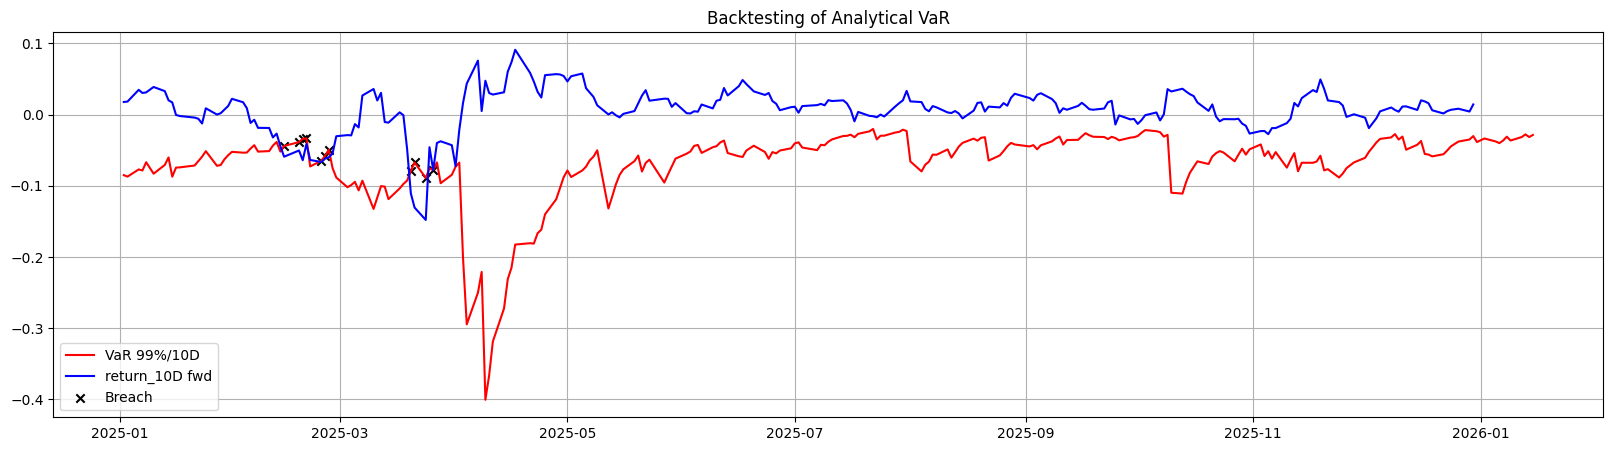

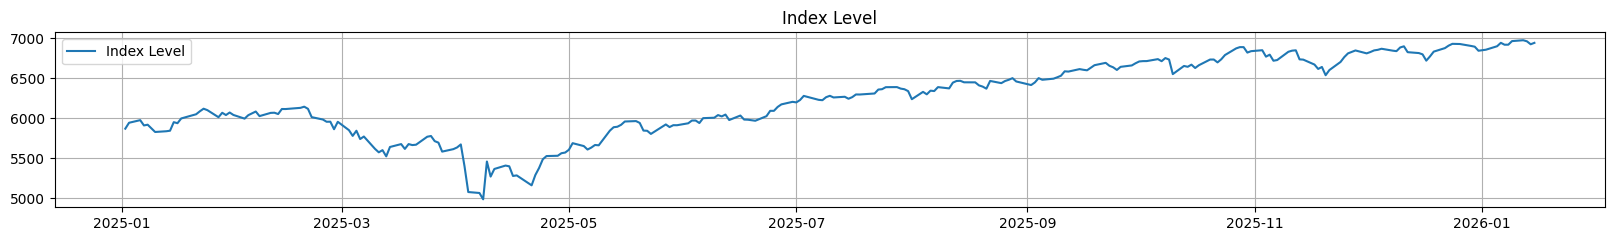

In [23]:
plt.title('Backtesting of Analytical VaR')
fig_size = plt.rcParams["figure.figsize"]
fig_size[0] = 20
fig_size[1] = 5
plt.rcParams["figure.figsize"] = fig_size
#fig, ax = plt.subplots()
#ax.set_xlim(0, 1009)
varPlt, = plt.plot(data.index, data['VaR'], color='RED')
r10dplt, = plt.plot(data.index, data['Forward10dReturn'], color='BLUE')
varBreachPlt = plt.scatter(data_breach.index, data_breach['VaR'], color='BLACK', marker='x')
plt.legend(["VaR 99%/10D","return_10D fwd","Breach"])
plt.grid()
fig = plt.figure()
ax1 = fig.add_subplot(211)
ax1.set_title('Index Level')
ax1.plot(data.index, data['^GSPC'])
ax1.legend(["Index Level"])
ax1.grid()
plt.show()

### Answer (c)

Adaptivity Comparison
Among rolling-window volatility, EWMA, and historical simulation:

EWMA exhibits the best adaptivity because it assigns exponentially higher weight to recent returns and updates volatility instantaneously.

Rolling-window volatility has moderate adaptivity due to equal weighting and slow information decay.

Historical simulation shows the worst adaptivity because it does not model time-varying volatility and relies on static past distribution.